Python notebook to plot updated comparison plots of TIG algorithms against SOTA on the benchmark VRPTW instances of Solomon and Homberger & Gehring

Use:
To add a new algorithm for comparison, upload the "{vehicle\_routing\_results\_{benchmark_instance}_{ALGORITHM}.csv" file to vehicle_routing_files and add an additional line to the top_earners.csv file

In [17]:
import os
import glob
import re
import argparse

import pandas as pd
import matplotlib.pyplot as plt


def load_and_standardize(path):
    """Load and standardize VRPTW CSV files."""
    try:
        df = pd.read_csv(path, engine='python')
    except Exception:
        df = pd.read_csv(path, sep='\t', engine='python')

    # Standardize column names
    if 'instance_name' in df.columns:
        df = df.rename(columns={'instance_name': 'instance'})

    # Handle gap column variations
    gap_cols = ['gap_percent', 'RPD', 'rpd']
    gap_col = next((col for col in gap_cols if col in df.columns), None)
    if gap_col and gap_col != 'gap_percent':
        df = df.rename(columns={gap_col: 'gap_percent'})
    elif 'gap_percent' not in df.columns:
        raise KeyError(f"{path} missing gap column (expected 'gap_percent' or 'RPD')")

    # Handle time column
    if 'time_microseconds' in df.columns:
        df['time_seconds'] = df['time_microseconds'] / 1e6
    elif 'time_seconds' not in df.columns:
        df['time_seconds'] = 0.0

    required = {'instance', 'gap_percent', 'time_seconds'}
    if missing := required - set(df.columns):
        raise KeyError(f"{path} missing columns: {missing}")

    return df


def parse_vrptw_instances(df):
    """Parse VRPTW instance names to extract dataset, size, and index."""
    def _parse(name):
        if '_' in name:
            parts = name.split('_')
            if len(parts) < 2:
                raise ValueError(f"Bad instance format: {name}")
            dataset = parts[0]
            try:
                size = int(parts[1])
            except ValueError:
                raise ValueError(f"Cannot parse size from instance '{name}'")
            idx = int(parts[2]) if len(parts) > 2 else None
        else:
            # Solomon format: PREFIX + group-digit + two-digit index
            m = re.match(r"^([A-Za-z]+)([12])(\d{2})$", name)
            if not m:
                raise ValueError(f"Unsupported Solomon instance format: {name}")
            prefix, size_group, idx_str = m.groups()
            dataset = f"{prefix}{size_group}"
            size = int(size_group) * 100
            idx = int(idx_str)
        return pd.Series({'dataset': dataset, 'size': size, 'index': idx})

    parsed = df['instance'].apply(_parse)
    return pd.concat([df, parsed], axis=1)


def summarize(df):
    """Summarize data by dataset and size."""
    # Summary by dataset
    sum_by_dataset = (
        df.groupby('dataset')
          .agg(avg_gap_percent=('gap_percent', 'mean'),
               total_time_seconds=('time_seconds', 'sum'))
          .reset_index()
    )

    # Add ALL row
    total_ds = {
        'dataset': 'ALL',
        'avg_gap_percent': df['gap_percent'].mean(),
        'total_time_seconds': df['time_seconds'].sum()
    }
    sum_by_dataset = pd.concat([sum_by_dataset, pd.DataFrame([total_ds])], ignore_index=True)

    # Summary by size
    sum_by_size = (
        df.groupby('size')
          .agg(avg_gap_percent=('gap_percent', 'mean'),
               total_time_seconds=('time_seconds', 'sum'))
          .reset_index()
    )

    total_sz = {
        'size': 'ALL',
        'avg_gap_percent': df['gap_percent'].mean(),
        'total_time_seconds': df['time_seconds'].sum()
    }
    sum_by_size = pd.concat([sum_by_size, pd.DataFrame([total_sz])], ignore_index=True)

    return sum_by_dataset, sum_by_size


def load_mapping_and_sota(root_folder, mapping_file, hgsadc_file):
    """Load mapping file and compute SOTA gap."""
    mapping_path = os.path.join(root_folder, mapping_file)

    hgsadc_path = os.path.join(root_folder, hgsadc_file)


    # Load and prepare mapping
    mapping = pd.read_csv(mapping_path)
    if 'name' not in mapping.columns or 'round' not in mapping.columns:
        raise KeyError(f"{mapping_path} missing 'name' or 'round' columns")
    mapping = mapping[['name', 'round']].rename(columns={'name': 'algorithm'})

    # Load and compute SOTA gap
    hgs = load_and_standardize(hgsadc_path)
    hgs = parse_vrptw_instances(hgs)
    sota_gap = hgs['gap_percent'].mean()

    return mapping, sota_gap


def process_algorithm_results(root_folder, dataset, mapping):
    """Process results for a specific dataset."""
    pattern = os.path.join(root_folder, f"vehicle_routing_results_{dataset}_*.csv")
    alg_files = glob.glob(pattern)

    if not alg_files:
        print(f"Warning: No files found matching: {pattern}")
        return pd.DataFrame()

    records = []
    for fp in alg_files:
        alg_name = os.path.splitext(os.path.basename(fp))[0].split(f"vehicle_routing_results_{dataset}_")[-1]
        df = load_and_standardize(fp)
        df = parse_vrptw_instances(df)
        sum_ds, _ = summarize(df)

        # Get overall average
        all_row = sum_ds[sum_ds['dataset'] == 'ALL']
        if all_row.empty:
            avg_gap = df['gap_percent'].mean()
            total_time = df['time_seconds'].sum()
        else:
            avg_gap = float(all_row['avg_gap_percent'].iloc[0])
            total_time = float(all_row['total_time_seconds'].iloc[0])

        records.append({
            'algorithm': alg_name,
            'avg_gap_percent': avg_gap,
            'total_time_seconds': total_time
        })

    overall_df = pd.DataFrame(records)

    # Merge with mapping
    comp = (
        mapping[mapping['algorithm'].isin(overall_df['algorithm'])]
        .merge(overall_df, on='algorithm', how='inner')
        .sort_values('round')
        .reset_index(drop=True)
    )

    if comp.empty:
        print(f"Warning: No matching algorithms found for {dataset}")
        print(f"Algorithms in mapping: {mapping['algorithm'].unique()}")
        print(f"Algorithms in results: {overall_df['algorithm'].unique()}")

    return comp


def plot_tig_vs_hgsadc_comparison(root_folder, mapping_file, hgsadc_file):
    """Compare TIG algorithms vs HGSADC SOTA with 2 subplots (Sol and GH)."""
    mapping, sota_gap = load_mapping_and_sota(root_folder, mapping_file, hgsadc_file)

    # Process both datasets
    datasets = ['Sol', 'GH']
    results = {dataset: process_algorithm_results(root_folder, dataset, mapping)
               for dataset in datasets}

    # Create plot
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.subplots_adjust(top=0.85)

    def plot_subplot(ax, comp, dataset_name, sota_gap):
        if comp.empty:
            ax.text(0.5, 0.5, f'No data for {dataset_name}',
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{dataset_name}')
            return

        # Plot algorithm performance
        ax.step(comp['round'], comp['avg_gap_percent'], where='mid',
               color='b', label='TIG Algo')

        # Add SOTA baseline
        xmin, xmax = comp['round'].min(), comp['round'].max()
        ax.hlines(sota_gap, xmin, xmax, colors='white', linestyles='--', label='HGSADC')

        # Add algorithm labels
        prev_alg = None
        for _, row in comp.iterrows():
            if row['algorithm'] != prev_alg:
                ax.text(row['round'], row['avg_gap_percent'], row['algorithm'],
                       rotation=45, va='bottom', ha='left', fontsize=8)
                prev_alg = row['algorithm']

        ax.set_title(f'{dataset_name}')
        ax.set_xlabel('Round')
        ax.set_ylabel('Average Gap %')
        ax.set_xlim(xmin, xmax)

    # Plot both datasets
    for i, dataset in enumerate(datasets):
        plot_subplot(axes[i], results[dataset], dataset, sota_gap)

    # Add legend
    if not all(results[ds].empty for ds in datasets):
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=2,
                  bbox_to_anchor=(0.5, 0.95), fontsize=10)

    fig.suptitle('VRPTW: TIG Algorithms vs HGSADC SOTA', fontsize=14)
    plt.tight_layout()
    plt.show()

    return results


def plot_by_dataset_type(root_folder, mapping_file, hgsadc_file):
    """Plot TIG algorithm performance by Solomon dataset type."""
    mapping, sota_gap = load_mapping_and_sota(root_folder, mapping_file, hgsadc_file)

    # Process all result files
    records = []
    pattern = os.path.join(root_folder, 'vehicle_routing_results_*_*.csv')
    for fp in glob.glob(pattern):
        alg_full = os.path.splitext(os.path.basename(fp))[0].replace('vehicle_routing_results_', '')
        df = load_and_standardize(fp)
        df = parse_vrptw_instances(df)
        sum_ds, _ = summarize(df)
        sum_ds = sum_ds[sum_ds['dataset'] != 'ALL']

        for _, r in sum_ds.iterrows():
            records.append({
                'dataset': r['dataset'],
                'algorithm_full': alg_full,
                'avg_gap_percent': r['avg_gap_percent']
            })

    # Build and process DataFrame
    comp = pd.DataFrame(records)
    split = comp['algorithm_full'].str.split('_', n=1, expand=True)
    comp['source'] = split[0]
    comp['algorithm'] = split[1]
    comp.drop(columns=['algorithm_full'], inplace=True)

    # Filter algorithms in mapping
    missing = [alg for alg in comp['algorithm'].unique()
               if alg not in mapping['algorithm'].unique()]
    if missing:
        print(f"Warning: skipping algorithms not in mapping: {missing}")
        comp = comp[comp['algorithm'].isin(mapping['algorithm'])]

    # Merge with mapping and aggregate
    comp = (comp.merge(mapping, on='algorithm', how='inner')
            .groupby(['dataset', 'algorithm', 'round'], as_index=False)
            .agg(avg_gap_percent=('avg_gap_percent', 'mean'))
            .sort_values(['dataset', 'round']))

    # Create subplots
    types = sorted(comp['dataset'].unique())
    cols, rows = 3, (len(types) + 2) // 3

    plt.style.use('dark_background')
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4), squeeze=False)
    axes = axes.flatten()

    for i, d in enumerate(types):
        ax = axes[i]
        subset = comp[comp['dataset'] == d].sort_values(['round', 'algorithm']).reset_index(drop=True)

        ax.step(subset['round'], subset['avg_gap_percent'], color='b', linestyle='-')

        # Label algorithm changes
        for j, r in subset.iterrows():
            if j == 0 or r['algorithm'] != subset.loc[j-1, 'algorithm']:
                ax.text(r['round'], r['avg_gap_percent'], r['algorithm'],
                       rotation=45, va='bottom', ha='left', fontsize=8)

        xmin, xmax = subset['round'].min(), subset['round'].max()
        ax.hlines(sota_gap, xmin, xmax, linestyles='--', label='HGSADC')
        ax.set_title(d)
        ax.set_xlabel('Round')
        ax.set_ylabel('Avg Gap %')
        ax.set_xlim(xmin, xmax)
        ax.legend()

    # Remove unused axes
    for j in range(len(types), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('TIG Algorithm Performance by Solomon Dataset Type', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return comp


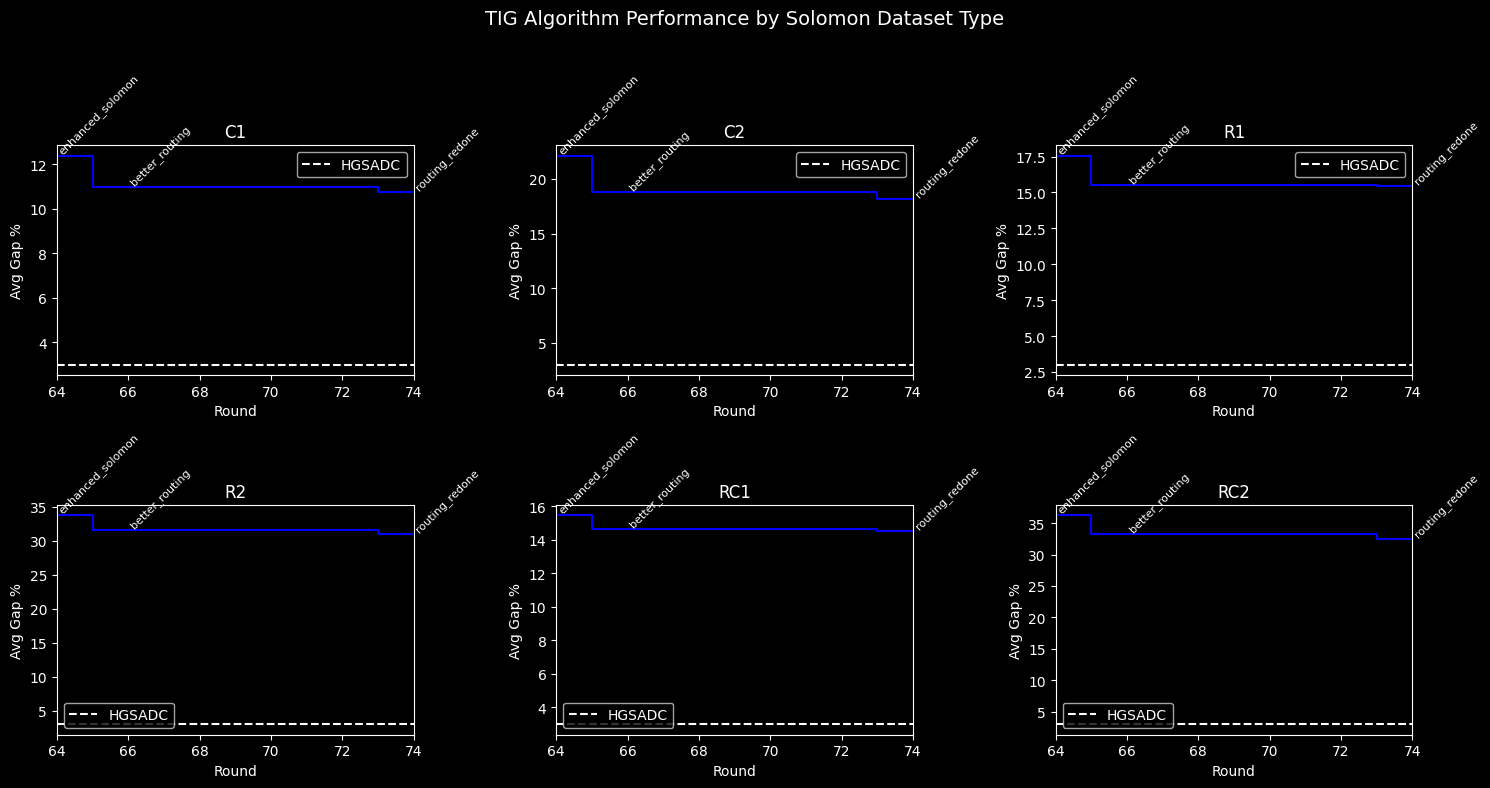

In [19]:
results = plot_by_dataset_type(root_folder, mapping_file, hgsadc_file)